

## 1. Regression Phase: Predicting Property Prices
**Business Objective:** Our primary goal is to predict the continuous target variable (`price`) of an Airbnb listing based on its features (location, room type, availability, etc.). Accurate price prediction helps hosts set competitive rates and allows guests to identify over-priced or under-priced properties.

**Methodology:**
1. **Data Cleaning & Noise Reduction:** We drop highly unique text columns (`name`, `host_name`, `neighbourhood`) that add noise to the linear model. We also fill missing values in `reviews_per_month` with zero.
2. **Outlier Handling:** We remove the top 5% most expensive listings and any $0 listings. Extreme luxury prices act as outliers that heavily skew the linear regression line, so removing them helps the model learn the "normal" market baseline.
3. **Smart Encoding:** We apply One-Hot Encoding to categorical variables (`room_type`, `neighbourhood_group`). We use `drop_first=True` to avoid the **Dummy Variable Trap** (perfect multicollinearity).
4. **Advanced Feature Engineering (Polynomial Expansion):** Standard Multiple Linear Regression assumes a strict straight-line relationship and struggles with spatial data (coordinates). We apply `PolynomialFeatures (degree=2)` to mathematically square the features and create interaction terms (e.g., Latitude × Longitude). This transforms our rigid model into a flexible one capable of capturing geographical hotspots.
5. **Evaluation:** We split the data (65% Train, 35% Test) and evaluate the model using R-squared (R2) and Mean Absolute Error (MAE).

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Load the full dataset
df = pd.read_csv("airbnb_cleaned.csv")

In [5]:


# 2. Drop text-heavy columns that cause noise and do not help the linear model
cols_to_drop = ['name', 'host_name', 'neighbourhood']
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# 3. Handle missing values (if some apartments have no reviews, fill with 0)
if 'reviews_per_month' in df_clean.columns:
    df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

# 4. Remove extreme outliers (Keep the normal 95% of prices to help the linear model)
q = df_clean['price'].quantile(0.95)
df_final = df_clean[(df_clean['price'] > 0) & (df_clean['price'] < q)].copy()

# 5. Convert categorical text (room type and neighborhood) into numerical columns (One-Hot Encoding)
cat_cols = ['room_type', 'neighbourhood_group']
df_encoded = pd.get_dummies(df_final, columns=cat_cols, drop_first=True)

# 6. Separate independent variables (X) and the target variable (y, which is price)
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# 7. Split the data into training (65%) and testing (35%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

# 🌟 8. The Magic Secret: Polynomial Features 🌟
# This step expands the linear equation to accommodate geographical curves and feature interactions
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 9. Train the Multiple Linear Regression model on the expanded data
model = LinearRegression()
model.fit(X_train_poly, y_train)

# 10. Make predictions and calculate accuracy metrics
y_pred = model.predict(X_test_poly)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("--- 🚀 FINAL Multiple Linear Regression Model 🚀 ---")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

--- 🚀 FINAL Multiple Linear Regression Model 🚀 ---
R-squared (R2) Score: 0.5714
Mean Absolute Error (MAE): 26.7681


In [6]:
# Save clean, ready-made data in a separate new file
df_encoded.to_csv("airbnb_ready_for_model.csv", index=False)
print("airbnb_ready_for_model.csv")

airbnb_ready_for_model.csv


## 2. Classification Phase: Predicting Property Price Category
**Business Objective:** In this phase, we want to classify whether an Airbnb listing is "Premium" (Above Median Price) or "Affordable" (Below Median Price). This helps users quickly identify if a property fits a budget-friendly category based on its location, availability, and reviews.

**Methodology:** 
1. We will calculate the median price of the dataset.
2. We will create a new binary target variable `price_category` (1 = Premium, 0 = Affordable).
3. We will train a **Random Forest Classifier**, which is an ensemble learning method robust to overfitting and excellent for capturing non-linear relationships in tabular data.
4. We will evaluate the model using Accuracy, Precision, Recall, and F1-Score.



In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the data
df = pd.read_csv("airbnb_cleaned.csv")

# 2. Basic Cleaning (Drop text noise & fill NaNs)
df_clean = df.drop(columns=['name', 'host_name', 'neighbourhood'], errors='ignore')
if 'reviews_per_month' in df_clean.columns:
    df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

# Remove extreme outliers for realistic modeling
q = df_clean['price'].quantile(0.95)
df_final = df_clean[(df_clean['price'] > 0) & (df_clean['price'] < q)].copy()

# 3. Create the Target Variable for Classification (1 = Premium, 0 = Affordable)
median_price = df_final['price'].median()
df_final['price_category'] = (df_final['price'] > median_price).astype(int)

# 4. Encoding
cat_cols = ['room_type', 'neighbourhood_group']
df_encoded = pd.get_dummies(df_final, columns=cat_cols, drop_first=True, dtype=int)

# 5. Define Features (X) and Target (y) 
# Note: We MUST drop the original 'price' column so the model doesn't cheat!
X = df_encoded.drop(columns=['price', 'price_category'])
y = df_encoded['price_category']

# 6. Train-Test Split (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 7. Train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train, y_train)

# 8. Predictions & Evaluation
y_pred = rf_classifier.predict(X_test)

print("--- Random Forest Classification Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Affordable (0)', 'Premium (1)']))

--- Random Forest Classification Results ---
Accuracy: 83.00%

Classification Report:
                precision    recall  f1-score   support

Affordable (0)       0.84      0.84      0.84      6620
   Premium (1)       0.82      0.82      0.82      6158

      accuracy                           0.83     12778
     macro avg       0.83      0.83      0.83     12778
  weighted avg       0.83      0.83      0.83     12778



## 3. Clustering Phase: Market Segmentation using K-Means
**Business Objective:** In this phase, we want to segment the Airbnb market into distinct clusters based on their geographical coordinates (`latitude`, `longitude`) and `price`. This helps in understanding the spatial distribution of different pricing tiers across the city.

**Methodology:** 
1. We select the numerical features: `latitude`, `longitude`, and `price`.
2. We apply **StandardScaler** to normalize the data. This is a crucial step because K-Means is a distance-based algorithm, and differences in scale (e.g., coordinates vs. price) can distort the clusters.
3. We apply the **K-Means algorithm** with `k=3` to identify three main market segments.
4. We evaluate the clusters by analyzing their statistical summaries and visualizing them on a scatter plot.

--- K-Means Clustering Summary ---
         Count  Average_Price  Min_Price  Max_Price
Cluster                                            
0        10766          78.46         10        246
1        14228         169.29         89        249
2        17597          76.31         10        230




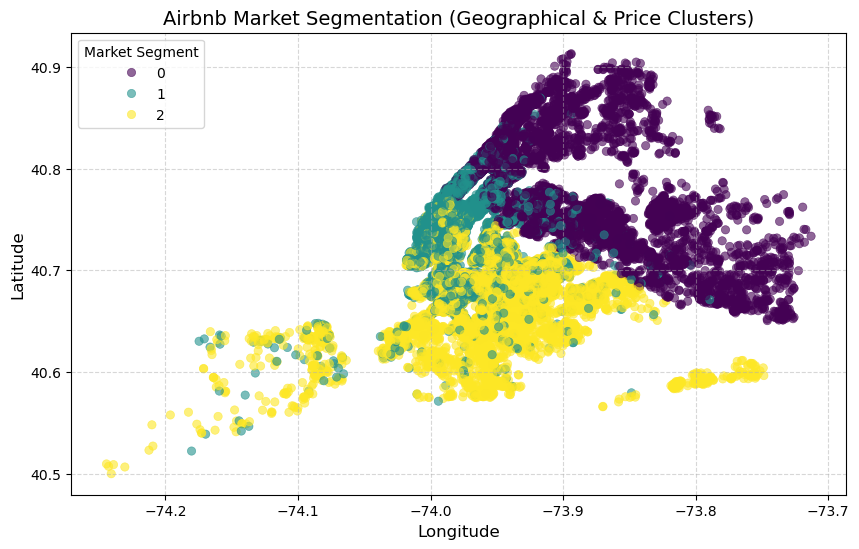

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load and prepare the data (using the same cleaned logic)
df = pd.read_csv("airbnb_cleaned.csv")
df_clean = df.drop(columns=['name', 'host_name', 'neighbourhood'], errors='ignore')
q = df_clean['price'].quantile(0.95)
df_final = df_clean[(df_clean['price'] > 0) & (df_clean['price'] < q)].copy()

# 2. Select Features for Clustering (Location + Price)
features_to_cluster = ['latitude', 'longitude', 'price']
X_cluster = df_final[features_to_cluster]

# 3. Scale the Data (Extremely important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 4. Train the K-Means Model (Finding 3 market segments)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_final['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Analyze the Clusters (Print Business Insights)
print("--- K-Means Clustering Summary ---")
cluster_summary = df_final.groupby('Cluster')['price'].agg(
    Count='count', 
    Average_Price='mean', 
    Min_Price='min', 
    Max_Price='max'
).round(2)
print(cluster_summary)
print("\n")

# 6. Visualize the Clusters
plt.figure(figsize=(10, 6))
# Plotting the clusters geographically
sns.scatterplot(
    x='longitude', 
    y='latitude', 
    hue='Cluster', 
    palette='viridis', 
    data=df_final, 
    alpha=0.6, 
    edgecolor=None
)

plt.title('Airbnb Market Segmentation (Geographical & Price Clusters)', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(title='Market Segment')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4. Anomaly Detection: Identifying Unusual Listings
**Business Objective:** In this final modeling phase, we aim to detect anomalous properties (outliers) using the **One-Class SVM** algorithm. These are listings that behave unusually compared to the rest of the market (e.g., extremely high prices in typically affordable neighborhoods, or strange review-to-price ratios). Identifying these helps platforms flag potentially fake listings or extreme luxury properties.

In [9]:
import pandas as pd
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

# 1. Load Data (Using a smaller sample for SVM to run faster)
df = pd.read_csv("airbnb_cleaned.csv")
df_clean = df.drop(columns=['name', 'host_name', 'neighbourhood'], errors='ignore')
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

# 2. Select numerical features for anomaly detection
features_anomaly = ['price', 'latitude', 'longitude', 'number_of_reviews']
X_anomaly = df_clean[features_anomaly].dropna()

# Standardize the data
scaler_ano = StandardScaler()
X_scaled_ano = scaler_ano.fit_transform(X_anomaly)

# 3. Train One-Class SVM (We expect about 1% of data to be real anomalies)
svm_model = OneClassSVM(nu=0.01, kernel="rbf", gamma="scale")
predictions = svm_model.fit_predict(X_scaled_ano)

# 4. Attach results back to the dataframe (-1 means Anomaly, 1 means Normal)
X_anomaly['Anomaly'] = predictions

# 5. Extract and show the Anomalies
anomalies = X_anomaly[X_anomaly['Anomaly'] == -1]

print("--- Anomaly Detection Results ---")
print(f"Total properties analyzed: {len(X_anomaly)}")
print(f"Number of unusual properties (Anomalies) detected: {len(anomalies)}")
print("\nSample of Anomalous Properties:")
print(anomalies[['price', 'number_of_reviews', 'latitude', 'longitude']].head())

--- Anomaly Detection Results ---
Total properties analyzed: 45840
Number of unusual properties (Anomalies) detected: 458

Sample of Anomalous Properties:
     price  number_of_reviews  latitude  longitude
7       79                430  40.76489  -73.98493
57      69                289  40.75531  -73.99293
64      52                191  40.75979  -73.99119
107     59                334  40.75527  -73.99291
110    120                467  40.66853  -73.98912
